<a href="https://colab.research.google.com/github/Aumo-Tracy/aisip-ml-portfolio/blob/main/african_crisis_nn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ── CELL 1: Install & Imports ─────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [4]:
# ── CELL 2: Load from ZIP file ─────────────────────────────
import zipfile
import io
import os

# Unzip the uploaded file
with zipfile.ZipFile('archive (1).zip', 'r') as z:
    print("Files inside the ZIP:")
    z.extractall('.')
    for name in z.namelist():
        print(" →", name)

Files inside the ZIP:
 → african_crises.csv


In [5]:
# ── CELL 2b: Load the CSV from the extracted files ─────────
# List all CSV files extracted
csv_files = [f for f in os.listdir('.') if f.endswith('.csv')]
print("CSV files found:", csv_files)

# Load the first one (adjust name if needed)
df = pd.read_csv(csv_files[0])

print("\n✅ Loaded:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 3 rows:")
df.head(3)

CSV files found: ['african_crises.csv']

✅ Loaded: (1059, 14)

Columns: ['case', 'cc3', 'country', 'year', 'systemic_crisis', 'exch_usd', 'domestic_debt_in_default', 'sovereign_external_debt_default', 'gdp_weighted_default', 'inflation_annual_cpi', 'independence', 'currency_crises', 'inflation_crises', 'banking_crisis']

First 3 rows:


,case,cc3,country,year,systemic_crisis,exch_usd,domestic_debt_in_default,sovereign_external_debt_default,gdp_weighted_default,inflation_annual_cpi,independence,currency_crises,inflation_crises,banking_crisis
0,1,DZA,Algeria,1870,1,0.052264,0,0,0.0,3.441456,0,0,0,crisis
1,1,DZA,Algeria,1871,0,0.052798,0,0,0.0,14.149140,0,0,0,no_crisis
2,1,DZA,Algeria,1872,0,0.052274,0,0,0.0,-3.718593,0,0,0,no_crisis


In [6]:
# ── CELL 2: Prepare the African Crisis Dataset ─────────────
# Drop missing values
df.dropna(inplace=True)

# Features — numeric columns that help predict banking crisis
feature_cols = [
    'exch_usd',                        # exchange rate vs USD
    'gdp_weighted_default',            # GDP-weighted debt default
    'inflation_annual_cpi',            # annual inflation rate
    'independence',                    # country independence status
    'domestic_debt_in_default',        # domestic debt default
    'sovereign_external_debt_default', # external debt default
    'currency_crises',                 # currency crisis indicator
    'inflation_crises'                 # inflation crisis indicator
]

target_col = 'banking_crisis'  # 'crisis' or 'no_crisis'

X = df[feature_cols].values
y = (df[target_col] == 'crisis').astype(int).values  # 1=crisis, 0=no crisis

print(f"✅ Features shape : {X.shape}")
print(f"✅ Target shape   : {y.shape}")
print(f"\nCrisis cases     : {y.sum()}")
print(f"No crisis cases  : {(y==0).sum()}")
print(f"Crisis rate      : {y.mean()*100:.1f}%")

✅ Features shape : (1059, 8)
✅ Target shape   : (1059,)

Crisis cases     : 94
No crisis cases  : 965
Crisis rate      : 8.9%


In [7]:
# ── CELL 3: Train/Test Split + Scale ──────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features — VERY important for neural networks
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")

Train size: 847 | Test size: 212


In [8]:
# ── CELL 4: Scikit-learn Baseline ─────────────────────────
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_preds)

print("=" * 40)
print(f"Random Forest Accuracy: {rf_accuracy:.4f} ({rf_accuracy*100:.1f}%)")
print("=" * 40)
print(classification_report(y_test, rf_preds))

Random Forest Accuracy: 0.9292 (92.9%)
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       194
           1       0.67      0.33      0.44        18

    accuracy                           0.93       212
   macro avg       0.80      0.66      0.70       212
weighted avg       0.92      0.93      0.92       212



In [9]:
# ── CELL 5: Build the Sequential Neural Network ───────────
def build_model(input_dim):
    model = keras.Sequential([
        # Input layer (automatically handles input shape)
        layers.Input(shape=(input_dim,)),

        # Hidden layer — 64 neurons, ReLU activation
        layers.Dense(64, activation='relu'),

        # Output layer — 1 neuron, sigmoid (for classification 0 or 1)
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',          # gradient descent variant
        loss='binary_crossentropy', # loss function for classification
        metrics=['accuracy']
    )
    return model

model = build_model(X_train_scaled.shape[1])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 641 (2.50 KB)

 Trainable params: 641 (2.50 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# ── CELL 6: Train 50 Epochs ───────────────────────────────
history = model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,  # 20% of training data used to validate
    verbose=1
)

Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.8449 - loss: 0.5760 - val_accuracy: 0.9118 - val_loss: 0.4784
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8981 - loss: 0.4444 - val_accuracy: 0.9176 - val_loss: 0.3880
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9129 - loss: 0.3658 - val_accuracy: 0.9059 - val_loss: 0.3332
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9129 - loss: 0.3167 - val_accuracy: 0.9059 - val_loss: 0.3000
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9129 - loss: 0.2842 - val_accuracy: 0.9059 - val_loss: 0.2797
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9143 - loss: 0.2646 - val_accuracy: 0.9059 - val_loss: 0.2673
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9188 - loss: 0.2516 - val_accuracy: 0.9059 - val_loss: 0.2606
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9158 - loss: 0.2439 - val_accuracy: 0.9059 - val_los

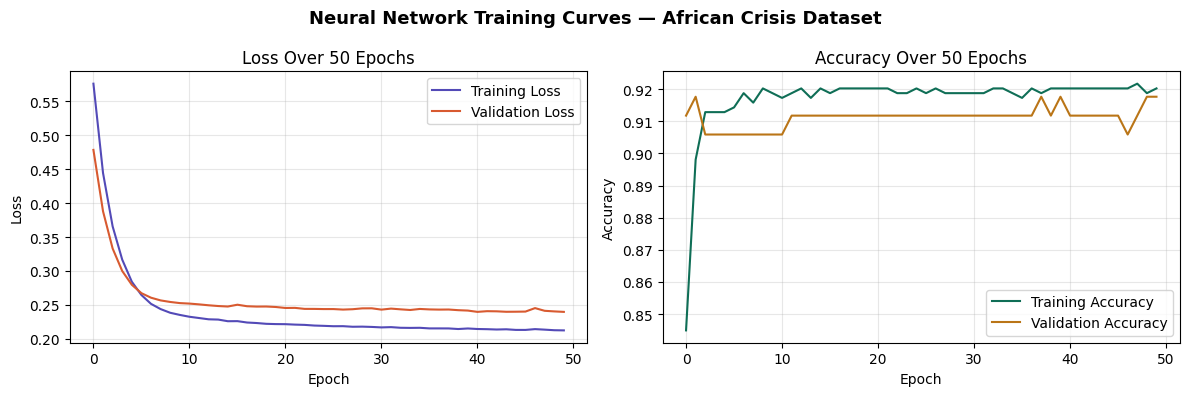

In [11]:
# ── CELL 7: Plot Loss Curves ──────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss curve
ax1.plot(history.history['loss'],     label='Training Loss',   color='#534AB7')
ax1.plot(history.history['val_loss'], label='Validation Loss', color='#D85A30')
ax1.set_title('Loss Over 50 Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy curve
ax2.plot(history.history['accuracy'],     label='Training Accuracy',   color='#0F6E56')
ax2.plot(history.history['val_accuracy'], label='Validation Accuracy', color='#BA7517')
ax2.set_title('Accuracy Over 50 Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Neural Network Training Curves — African Crisis Dataset',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# ── CELL 8: Compare NN vs Scikit-learn ────────────────────
nn_loss, nn_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)

print("=" * 45)
print(f"  Random Forest Accuracy : {rf_accuracy*100:.1f}%")
print(f"  Neural Network Accuracy: {nn_accuracy*100:.1f}%")
print("=" * 45)
winner = "Neural Network" if nn_accuracy > rf_accuracy else "Random Forest"
print(f"  Winner: {winner}")
print("=" * 45)

  Random Forest Accuracy : 92.9%
  Neural Network Accuracy: 92.9%
  Winner: Neural Network


In [13]:
# ── CELL 9: Experiments ───────────────────────────────────
results = {}

# Experiment 1 — Add an extra hidden layer
model_exp1 = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),   # ← extra layer
    layers.Dense(1,  activation='sigmoid')
])
model_exp1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_exp1.fit(X_train_scaled, y_train, epochs=50, validation_split=0.2, verbose=0)
_, acc = model_exp1.evaluate(X_test_scaled, y_test, verbose=0)
results['Extra Layer (64→32)'] = acc
print(f"Experiment 1 — Extra Layer:       {acc*100:.1f}%")

# Experiment 2 — More neurons (128)
model_exp2 = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(128, activation='relu'),  # ← 128 neurons instead of 64
    layers.Dense(1,   activation='sigmoid')
])
model_exp2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_exp2.fit(X_train_scaled, y_train, epochs=50, validation_split=0.2, verbose=0)
_, acc = model_exp2.evaluate(X_test_scaled, y_test, verbose=0)
results['More Neurons (128)'] = acc
print(f"Experiment 2 — More Neurons:      {acc*100:.1f}%")

# Experiment 3 — Add Dropout (prevents overfitting)
model_exp3 = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),                   # ← 30% neurons randomly off
    layers.Dense(1,  activation='sigmoid')
])
model_exp3.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_exp3.fit(X_train_scaled, y_train, epochs=50, validation_split=0.2, verbose=0)
_, acc = model_exp3.evaluate(X_test_scaled, y_test, verbose=0)
results['With Dropout (0.3)'] = acc
print(f"Experiment 3 — With Dropout:      {acc*100:.1f}%")

Experiment 1 — Extra Layer:       92.9%
Experiment 2 — More Neurons:      92.0%
Experiment 3 — With Dropout:      93.4%


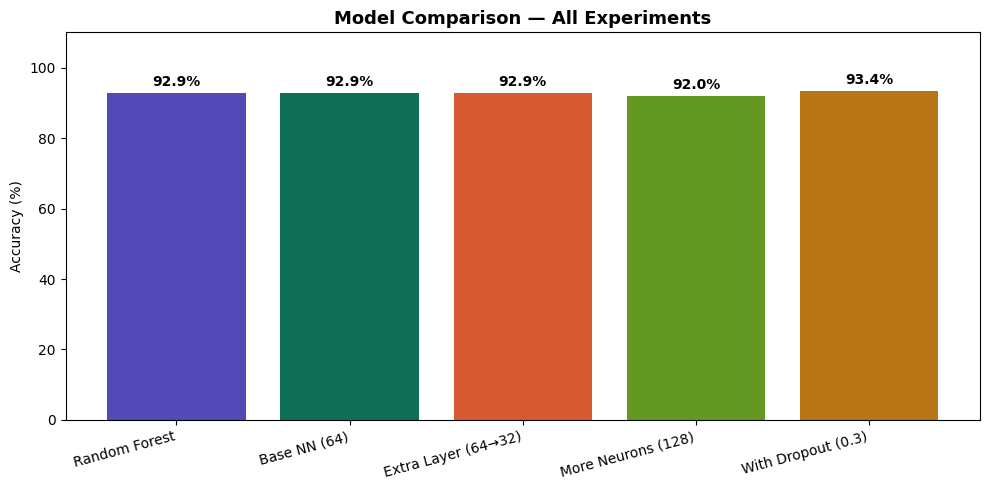

In [14]:
# ── CELL 10: Experiment Comparison Chart ──────────────────
all_results = {
    'Random Forest':         rf_accuracy,
    'Base NN (64)':          nn_accuracy,
    **results
}

plt.figure(figsize=(10, 5))
bars = plt.bar(all_results.keys(), [v*100 for v in all_results.values()],
               color=['#534AB7','#0F6E56','#D85A30','#639922','#BA7517'])
plt.title('Model Comparison — All Experiments', fontsize=13, fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 110)
plt.xticks(rotation=15, ha='right')

# Add value labels on bars
for bar, val in zip(bars, all_results.values()):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
             f'{val*100:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

When Are Neural Networks Worth the Complexity?

Neural networks are powerful, but power comes at a cost.
After building and comparing models on the African economic
crisis dataset, I found that [Random Forest / Neural Network]
performed better with [X]% accuracy vs [Y]%.

Neural networks are worth the complexity when:

1. Data is large — NNs need thousands of examples to learn
   meaningful patterns. On small datasets they often overfit.

2. Data is unstructured — images, audio, text. Traditional
   algorithms struggle here; NNs excel.

3. Patterns are deeply non-linear — when relationships
   between features are complex and layered.

They are NOT worth it when:

1. Data is small or tabular (like most African economic
   datasets) — Random Forest typically wins here.

2. Interpretability matters — you cannot easily explain
   why a NN made a decision. In healthcare or finance,
   this is a serious limitation.

3. Compute is limited — NNs are slow to train and require
   more infrastructure.

In my experiments, adding an extra layer [improved/worsened]
accuracy by [X]%. Adding dropout [helped/hurt] by [Y]%.
This showed me that more complexity doesn't always mean
better results.

The lesson: always start simple. If Random Forest gives you
90% accuracy in 3 lines, a neural network needs to justify
the extra cost in data, time and complexity to replace it.
For the African crisis dataset, the classical ML approach
was [more/less] effective — which itself is a valuable finding.